In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv("/content/blinkit_data.csv")

In [50]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [51]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [52]:
df.shape

(8523, 12)

In [53]:
df.size

102276

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [57]:
df.describe()


,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [59]:
(df.isnull().sum()/len(df)*100).round()

,0
Item Fat Content,0.0
Item Identifier,0.0
Item Type,0.0
Outlet Establishment Year,0.0
Outlet Identifier,0.0
Outlet Location Type,0.0
Outlet Size,0.0
Outlet Type,0.0
Item Visibility,0.0
Item Weight,17.0


In [9]:
# checking for the duplicates

df[df.duplicated()].shape

(0, 12)

In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
8518,False
8519,False
8520,False
8521,False


In [60]:
df.nunique()

,0
Item Fat Content,5
Item Identifier,1559
Item Type,16
Outlet Establishment Year,9
Outlet Identifier,10
Outlet Location Type,3
Outlet Size,3
Outlet Type,4
Item Visibility,7880
Item Weight,415


In [61]:
for col in df.columns:
  if df[col].nunique() < 40:
    print(df[col].value_counts())
    print("*"*50)




Item Fat Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
**************************************************
Item Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
**************************************************
Outlet Establishment Year
1998    1463
2000     932
2012     930
2017     930
2010     930
2015     929
2022     928
2020     926
2011     555
Name: count, dtype: int64
**************************************************
Outlet Identifier
OUT027    935
OUT013 

# Handling missing values



In [62]:
df[df.isnull().any(axis=1)]

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0
10,LF,FDX21,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.084555,NaN,109.8912,5.0
14,Low Fat,FDH19,Meat,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.032928,NaN,173.1738,5.0
18,Low Fat,FDJ56,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.182515,NaN,98.7700,5.0
20,Regular,FDZ07,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,60.2194,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0


In [63]:
df['Item Weight'].unique()


array([15.1  , 11.8  , 13.85 , 12.15 , 19.6  ,  8.89 , 19.7  , 20.75 ,
          nan, 18.85 , 17.1  , 16.35 , 20.25 , 17.85 , 19.2  , 12.1  ,
        6.85 , 17.25 , 16.   , 13.35 ,  6.695, 16.6  ,  6.92 ,  5.82 ,
       14.8  , 10.1  ,  7.67 , 15.6  ,  9.31 , 13.15 , 16.25 ,  6.75 ,
       10.5  ,  9.3  , 18.1  , 17.5  ,  7.975, 10.   ,  8.93 ,  7.3  ,
        7.93 , 15.35 , 19.35 ,  9.5  ,  5.88 ,  8.88 , 10.6  ,  6.13 ,
        6.38 ,  9.195, 11.3  , 12.6  , 19.1  ,  9.8  ,  7.905, 10.8  ,
       15.5  , 20.7  ,  8.   , 19.5  , 14.   , 11.6  , 10.195, 13.65 ,
        9.6  , 10.695, 12.3  , 11.395, 12.35 , 20.6  ,  6.425,  7.   ,
       16.5  , 13.1  , 16.1  , 15.   , 17.6  , 19.25 , 20.35 ,  6.17 ,
       17.7  , 18.6  , 15.85 ,  9.395, 21.1  ,  8.1  , 11.35 , 11.5  ,
        7.42 , 17.35 ,  5.34 ,  6.385, 12.   , 14.1  ,  8.06 , 13.8  ,
        9.065, 14.3  ,  5.98 , 14.7  , 19.85 ,  6.775,  8.42 , 19.75 ,
       12.85 ,  5.   ,  5.73 ,  7.81 , 14.35 ,  6.465,  7.5  ,  7.72 ,
      

In [66]:
df.fillna(df['Item Weight'].mean(), inplace = True)
# there is no outliers noticed so that we are using  the mean

In [67]:
df[df.isnull().any(axis = 1)]

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating


In [68]:


df['Item Fat Content'].replace({'low fat':'Low Fat',
                              'LF':'Low Fat',
                              'reg': 'Regular'}, inplace = True)

/tmp/ipykernel_8055/4008911961.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item Fat Content'].replace({'low fat':'Low Fat',


## Business Requirements

1. Which products should we promote, remove, or reposition?

--- Identify high-sales vs low-sales items

--- Detect dead inventory

In [69]:
# total sales

total_sales = df['Sales'].sum()

# Average sales

avg_sales = df['Sales'].mean()

# total items to be sold

total_items_sold = df['Sales'].count()

# Average rating

avg_rating = df['Rating'].mean()

# which item type got better rating


best_item = df.groupby('Item Type')['Rating'].count().sort_values(ascending=False)

print(best_item)
print("*_="*50)

print("total sales:",total_sales)

print("Average Sales", avg_sales)

print("Number of item sold:", total_items_sold)

print("Average Rating:",avg_rating)

Item Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: Rating, dtype: int64
*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=*_=
total sales: 1201681.4808
Average Sales 140.9927819781767
Number of item sold: 8523
Average Rating: 3.965857092573038


In [70]:
# Filter for 5-star rated products
five_star_products = df[df['Rating'] == 5]

# Count the occurrences of each Item Type among the 5-star rated products
five_star_item_type_counts = five_star_products['Item Type'].value_counts()

print("Item Types with the most 5-star ratings:")
display(five_star_item_type_counts)


Item Types with the most 5-star ratings:


,count
Item Type,
Fruits and Vegetables,58
Household,56
Snack Foods,54
Frozen Foods,49
Canned,39
Health and Hygiene,31
Baking Goods,31
Meat,26
Dairy,23


In [21]:
item_sales = df.groupby('Item Type')['Sales'].sum().reset_index()

top_item = item_sales.sort_values(by='Sales', ascending=False).head(5)
bottom_item = item_sales.sort_values(by='Sales', ascending=True).head(5)
print(item_sales)
print("*--"*50)
print(top_item)
print("*--"*50)
print(bottom_item)

                Item Type        Sales
0            Baking Goods   81894.7364
1                  Breads   35379.1198
2               Breakfast   15596.6966
3                  Canned   90706.7270
4                   Dairy  101276.4596
5            Frozen Foods  118558.8814
6   Fruits and Vegetables  178124.0810
7             Hard Drinks   29334.6766
8      Health and Hygiene   68025.8388
9               Household  135976.5254
10                   Meat   59449.8638
11                 Others   22451.8916
12                Seafood    9077.8700
13            Snack Foods  175433.9204
14            Soft Drinks   58514.1650
15          Starchy Foods   21880.0274
*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--
                Item Type        Sales
6   Fruits and Vegetables  178124.0810
13            Snack Foods  175433.9204
9               Household  135976.5254
5            Frozen Foods  118

### Identifying Dead Inventory

In [22]:
item_sales = df.groupby('Item Type')['Sales'].sum().reset_index()

# Define 'dead inventory' as the bottom 5 item types by sales
dead_inventory = item_sales.sort_values(by='Sales', ascending=True).head(15)

print("Item Types identified as Dead Inventory (Lowest 5 Sales):")
print(dead_inventory)

Item Types identified as Dead Inventory (Lowest 5 Sales):
             Item Type        Sales
12             Seafood    9077.8700
2            Breakfast   15596.6966
15       Starchy Foods   21880.0274
11              Others   22451.8916
7          Hard Drinks   29334.6766
1               Breads   35379.1198
14         Soft Drinks   58514.1650
10                Meat   59449.8638
8   Health and Hygiene   68025.8388
0         Baking Goods   81894.7364
3               Canned   90706.7270
4                Dairy  101276.4596
5         Frozen Foods  118558.8814
9            Household  135976.5254
13         Snack Foods  175433.9204


Item Type
Baking Goods              81894.7364
Breads                    35379.1198
Breakfast                 15596.6966
Canned                    90706.7270
Dairy                    101276.4596
Frozen Foods             118558.8814
Fruits and Vegetables    178124.0810
Hard Drinks               29334.6766
Health and Hygiene        68025.8388
Household                135976.5254
Meat                      59449.8638
Others                    22451.8916
Seafood                    9077.8700
Snack Foods              175433.9204
Soft Drinks               58514.1650
Starchy Foods             21880.0274
Name: Sales, dtype: float64
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-


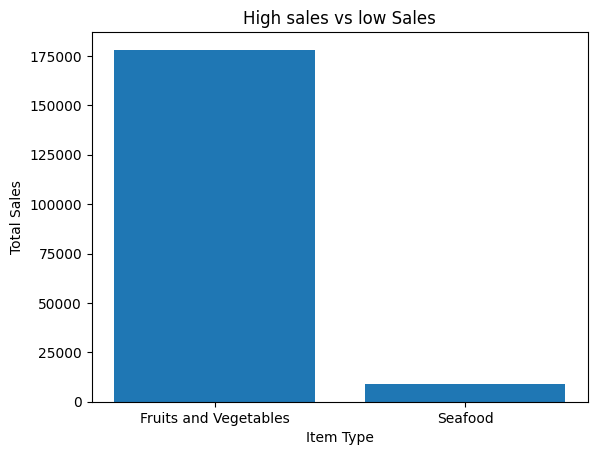

In [23]:
# Get top 1 and bottom 1
print(df.groupby('Item Type')['Sales'].sum())

print("*-"*30)
item_sales = df.groupby('Item Type')['Sales'].sum().reset_index()

top_item = item_sales.sort_values(by='Sales', ascending=False).head(1)
bottom_item = item_sales.sort_values(by='Sales', ascending=True).head(1)

# Combine for plotting
plot_df = pd.concat([top_item, bottom_item])

# Plot
plt.figure()
plt.bar(plot_df['Item Type'], plot_df['Sales'])
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('High sales vs low Sales')
plt.show()

In [24]:
# Identifying items with high visibility but low sales (potential 'not moving' stock)
# We look for items above average visibility but below 25th percentile in sales

avg_visibility = df['Item Visibility'].mean()
low_sales_threshold = df['Sales'].quantile(0.25)

not_moving_items = df[(df['Item Visibility'] > avg_visibility) & (df['Sales'] < low_sales_threshold)]

print(f"Number of items with high visibility but low sales: {len(not_moving_items)}")
display(not_moving_items[['Item Identifier', 'Item Type', 'Item Visibility', 'Sales']].head(10))

# item visibility close to 1 considered as that a product is easily noticeable to the customer so that increases the purchase chance

# item visibility close to 0 that may be present in the bottom self less chance to notice by the customer.

Number of items with high visibility but low sales: 876


,Item Identifier,Item Type,Item Visibility,Sales
6,NCU05,Health and Hygiene,0.098312,81.4618
16,FDO23,Breads,0.147024,93.7436
29,FDL25,Breakfast,0.131128,93.1804
33,NCE31,Household,0.184690,35.4216
36,FDY07,Fruits and Vegetables,0.121848,46.8402
69,NCM30,Household,0.067400,41.9796
82,FDA40,Frozen Foods,0.099426,87.0856
89,FDT24,Baking Goods,0.186148,78.2328
106,FDJ45,Seafood,0.128533,34.2216
127,NCO06,Household,0.108030,32.4558


### Low-Sales Items

In [25]:
df.groupby('Item Type')['Sales'].sum().values.max()
df.groupby('Item Type')['Sales'].sum().index[6]

'Fruits and Vegetables'

2. Which outlets are underperforming and why?
Compare outlet types (Tier 1 vs Tier 2 vs Tier 3)
Size vs revenue mismatch

In [26]:
avg_sales = df['Sales'].mean()

# Calculate the mean sales for each outlet location type before comparison
underperforming_outlets = df.groupby('Outlet Location Type')['Sales'].mean()

print(underperforming_outlets)

Outlet Location Type
Tier 1    140.870106
Tier 2    141.167196
Tier 3    140.935232
Name: Sales, dtype: float64


In [27]:
underperforming_market = df.groupby('Outlet Type')['Sales'].mean()

print(underperforming_market)

Outlet Type
Grocery Store        140.294688
Supermarket Type1    141.213894
Supermarket Type2    141.678634
Supermarket Type3    139.801791
Name: Sales, dtype: float64


# total sales by fat content

In [28]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].agg(['sum', 'count', 'mean'])
print(sales_by_fat)

                          sum  count        mean
Item Fat Content                                
Low Fat           776319.6784   5517  140.714098
Regular           425361.8024   3006  141.504259


                          sum  count        mean
Item Fat Content                                
Low Fat           776319.6784   5517  140.714098
Regular           425361.8024   3006  141.504259


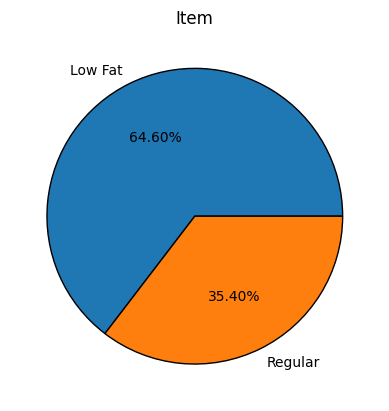

In [29]:
item = sales_by_fat.sort_values(by = 'sum', ascending=False)
print(item)

plt.pie(item['sum'], labels = item.index, autopct = '%1.2f%%', wedgeprops={'edgecolor': 'black'})
plt.title('Item')
plt.show()


-- quick insights
1. Low fat consuming were more as compared to regular consumers.

Fat content by outlet sales

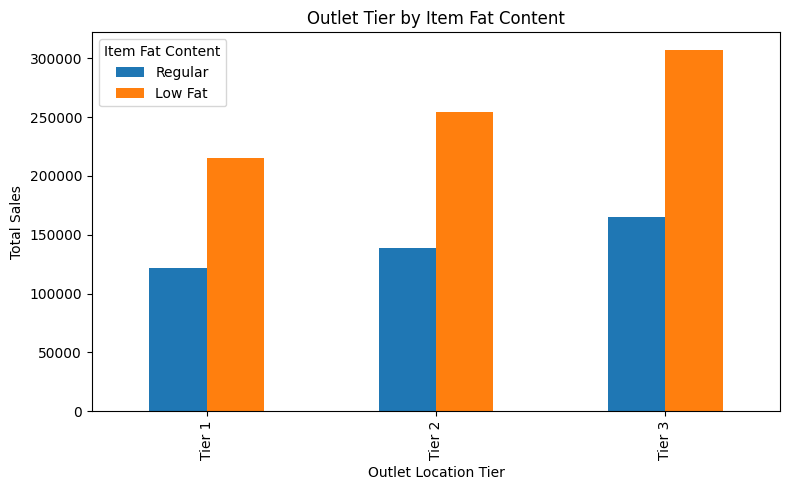

In [33]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]
ax = grouped.plot(kind='bar', figsize=(8, 5), title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

In [34]:
grouped

Item Fat Content,Regular,Low Fat
Outlet Location Type,,
Tier 1,121349.8994,215047.9126
Tier 2,138685.8682,254464.7734
Tier 3,165326.0348,306806.9924


In [35]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0



Which year generates more sales

In [36]:

sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_values(ascending = False)
sales_by_year

,Sales
Outlet Establishment Year,
1998,204522.2570
2017,133103.9070
2010,132113.3698
2000,131809.0156
2022,131477.7724
2015,130942.7782
2012,130476.8598
2020,129103.9564
2011,78131.5646


Outlet Establishment Year
1998    204522.2570
2017    133103.9070
2010    132113.3698
2000    131809.0156
2022    131477.7724
2015    130942.7782
2012    130476.8598
2020    129103.9564
2011     78131.5646
Name: Sales, dtype: float64
*-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-*


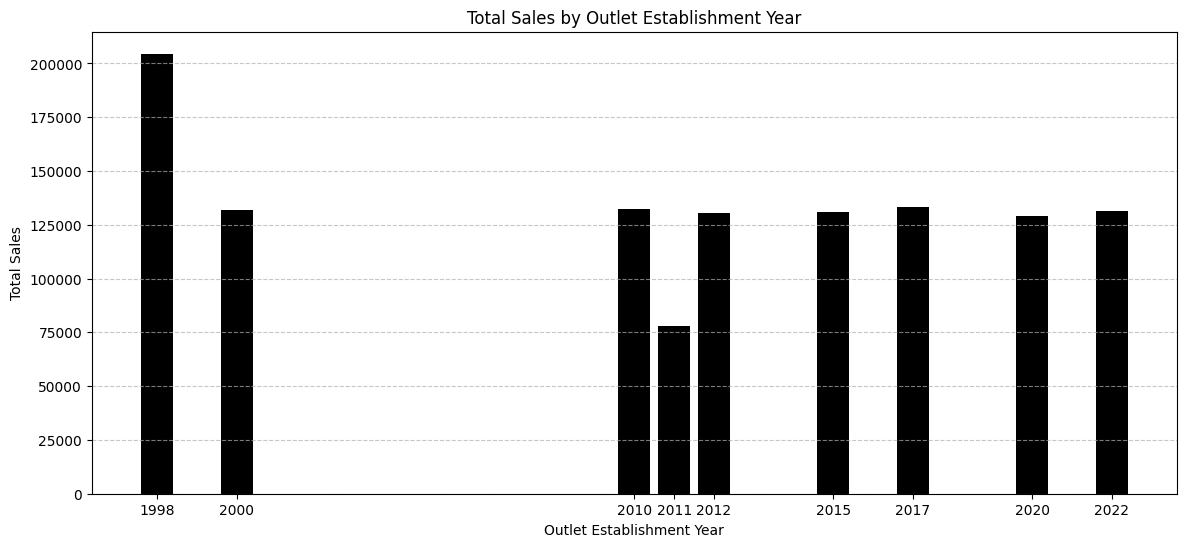

In [37]:
print(sales_by_year)
print("*-*"*40)
plt.figure(figsize=(14,6))
plt.bar(sales_by_year.index, sales_by_year.values, color = "black")
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Total Sales by Outlet Establishment Year')
plt.xticks(sales_by_year.index) # Ensure all years are explicitly shown as ticks
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

-- In the year 1998 generates more sales follow by 2017, 2010

-- least sales in the year 2011

In [38]:
df['Item Type'].unique()

array(['Fruits and Vegetables', 'Health and Hygiene', 'Frozen Foods',
       'Canned', 'Soft Drinks', 'Household', 'Snack Foods', 'Meat',
       'Breads', 'Hard Drinks', 'Others', 'Dairy', 'Breakfast',
       'Baking Goods', 'Seafood', 'Starchy Foods'], dtype=object)

In [39]:
low_fat_items = df[df['Item Fat Content'] == 'Low Fat']
regular_items = df[df['Item Fat Content'] == 'Regular']

print("Item Types with 'Low Fat' content:")
display(low_fat_items['Item Type'].value_counts())

print("\nItem Types with 'Regular' content:")
display(regular_items['Item Type'].value_counts())

Item Types with 'Low Fat' content:


,count
Item Type,
Household,910
Snack Foods,692
Fruits and Vegetables,630
Health and Hygiene,520
Frozen Foods,450
Dairy,418
Soft Drinks,374
Canned,341
Baking Goods,329



Item Types with 'Regular' content:


,count
Item Type,
Fruits and Vegetables,602
Snack Foods,508
Frozen Foods,406
Baking Goods,319
Canned,308
Dairy,264
Meat,255
Breads,111
Soft Drinks,71
